# Notebook 01 — Exploración del Corpus
## Proyecto 3 · Minería de Textos · CUC

**Curso:** Minería de Textos  
**Profesor:** Osvaldo González Chaves  
**Dataset:** `tcc_ceds_music.csv` — Music Dataset 1950–2019

Contenido:
1. Instalación
2. Estadísticas generales
3. Distribución por género y década
4. Análisis de letras
5. Variables emocionales
6. Muestras por género
7. Resumen

In [1]:
# Ejecutar solo la primera vez
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'pandas', 'numpy', 'matplotlib', 'seaborn'])

0

In [2]:
import sys
sys.path.insert(0, '../../../../AppData/Local')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RESULTS_DIR = Path('../resultados')
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('../data/tcc_ceds_music.csv', low_memory=False)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print(f'Corpus cargado: {len(df):,} canciones')
print(f'Columnas: {len(df.columns)}')
print(f'Con letra: {df["lyrics"].notna().sum():,}')
df.head(3)

Corpus cargado: 28,372 canciones
Columnas: 31
Con letra: 28,372


,unnamed:_0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0


## 1. Estadísticas generales

In [3]:
print('=' * 50)
print('  RESUMEN DEL CORPUS')
print('=' * 50)
print(f'Total canciones    : {len(df):,}')
print(f'Artistas unicos    : {df["artist_name"].nunique():,}')
print(f'Canciones unicas   : {df["track_name"].nunique():,}')
print(f'Generos            : {df["genre"].nunique()}')
print(f'Rango temporal     : {int(df["release_date"].min())} - {int(df["release_date"].max())}')
print(f'Con letra completa : {df["lyrics"].notna().sum():,} ({df["lyrics"].notna().mean()*100:.1f}%)')
print()
print('Distribucion por genero:')
print(df['genre'].value_counts())

  RESUMEN DEL CORPUS
Total canciones    : 28,372
Artistas unicos    : 5,426
Canciones unicas   : 23,689
Generos            : 7
Rango temporal     : 1950 - 2019
Con letra completa : 28,372 (100.0%)

Distribucion por genero:
genre
pop        7042
country    5445
blues      4604
rock       4034
jazz       3845
reggae     2498
hip hop     904
Name: count, dtype: int64


## 2. Distribución por género y por década

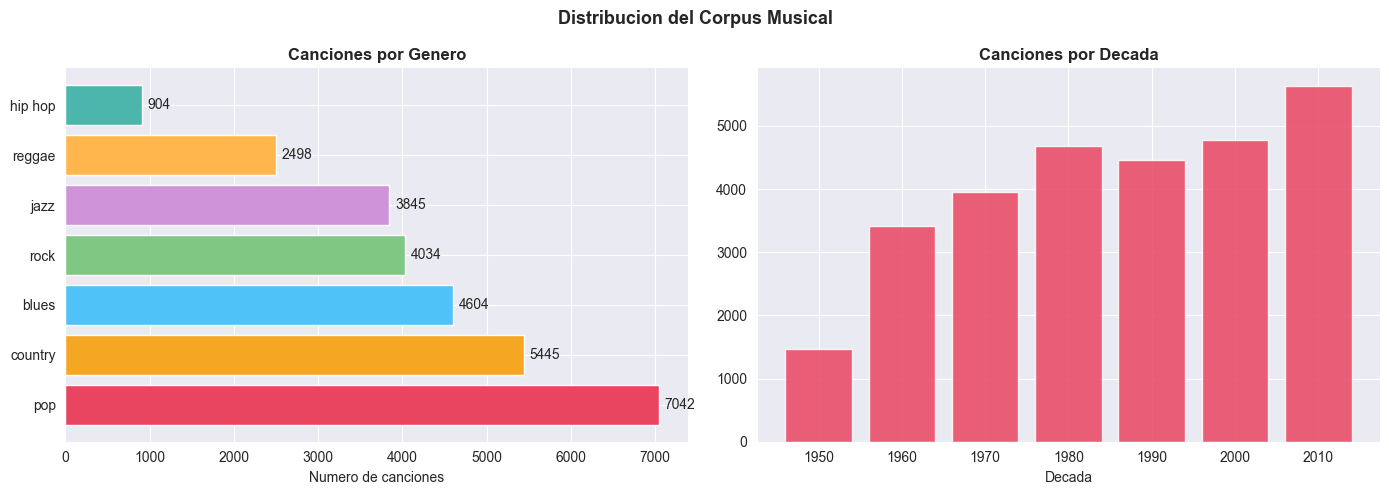

Grafica guardada.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['genre'].value_counts()
colors = ['#e94560','#f5a623','#4fc3f7','#81c784','#ce93d8','#ffb74d','#4db6ac']
bars = axes[0].barh(counts.index, counts.values, color=colors)
axes[0].bar_label(bars, fmt='%d', padding=4)
axes[0].set_title('Canciones por Genero', fontweight='bold')
axes[0].set_xlabel('Numero de canciones')
axes[0].spines[['top','right']].set_visible(False)

decades = (pd.to_numeric(df['release_date'], errors='coerce') // 10 * 10).value_counts().sort_index()
axes[1].bar(decades.index.astype(int), decades.values, color='#e94560', alpha=0.85, width=8)
axes[1].set_title('Canciones por Decada', fontweight='bold')
axes[1].set_xlabel('Decada')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Distribucion del Corpus Musical', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'corpus_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()
print('Grafica guardada.')

## 3. Análisis de letras

=== ANALISIS DE LETRAS ===
Longitud media    : 447 chars
Longitud mediana  : 384 chars
Palabras promedio : 73 palabras
Letras vacias     : 0

Longitud media por genero:
genre
hip hop    613.0
reggae     612.0
pop        480.0
jazz       451.0
rock       408.0
blues      385.0
country    379.0
Name: lyrics_len, dtype: float64


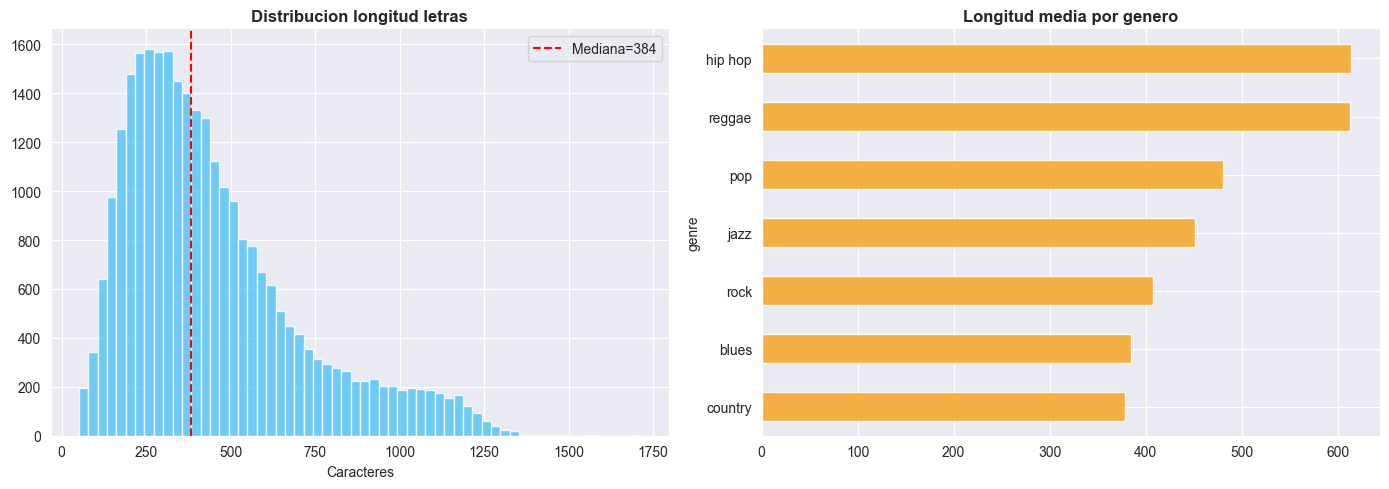

In [5]:
df['lyrics_len']   = df['lyrics'].fillna('').str.len()
df['lyrics_words'] = df['lyrics'].fillna('').str.split().str.len()

print('=== ANALISIS DE LETRAS ===')
print(f'Longitud media    : {df["lyrics_len"].mean():.0f} chars')
print(f'Longitud mediana  : {df["lyrics_len"].median():.0f} chars')
print(f'Palabras promedio : {df["lyrics_words"].mean():.0f} palabras')
print(f'Letras vacias     : {(df["lyrics_len"] == 0).sum():,}')
print()
print('Longitud media por genero:')
print(df.groupby('genre')['lyrics_len'].mean().sort_values(ascending=False).round(0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_con = df[df['lyrics_len'] > 50]
axes[0].hist(df_con['lyrics_len'], bins=60, color='#4fc3f7', alpha=0.8)
axes[0].axvline(df['lyrics_len'].median(), color='red', linestyle='--',
                label=f'Mediana={int(df["lyrics_len"].median())}')
axes[0].set_title('Distribucion longitud letras', fontweight='bold')
axes[0].set_xlabel('Caracteres')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

df.groupby('genre')['lyrics_len'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#f5a623', alpha=0.85)
axes[1].set_title('Longitud media por genero', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'letras_longitud.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Variables emocionales

El dataset incluye variables emocionales pre-calculadas útiles para el fine-tuning.

Columnas emocionales: ['sadness', 'romantic', 'violence', 'dating', 'danceability', 'energy', 'valence']

         sadness   romantic   violence     dating  danceability     energy  \
count  28372.000  28372.000  28372.000  28372.000     28372.000  28372.000   
mean       0.129      0.049      0.118      0.021         0.533      0.570   
std        0.181      0.106      0.179      0.052         0.173      0.244   
min        0.000      0.000      0.000      0.000         0.005      0.000   
25%        0.001      0.001      0.001      0.001         0.413      0.380   
50%        0.005      0.002      0.003      0.001         0.539      0.581   
75%        0.235      0.042      0.193      0.004         0.657      0.773   
max        0.981      0.941      0.982      0.648         0.994      1.000   

         valence  
count  28372.000  
mean       0.533  
std        0.251  
min        0.000  
25%        0.329  
50%        0.539  
75%        0.738  
max        1.000  


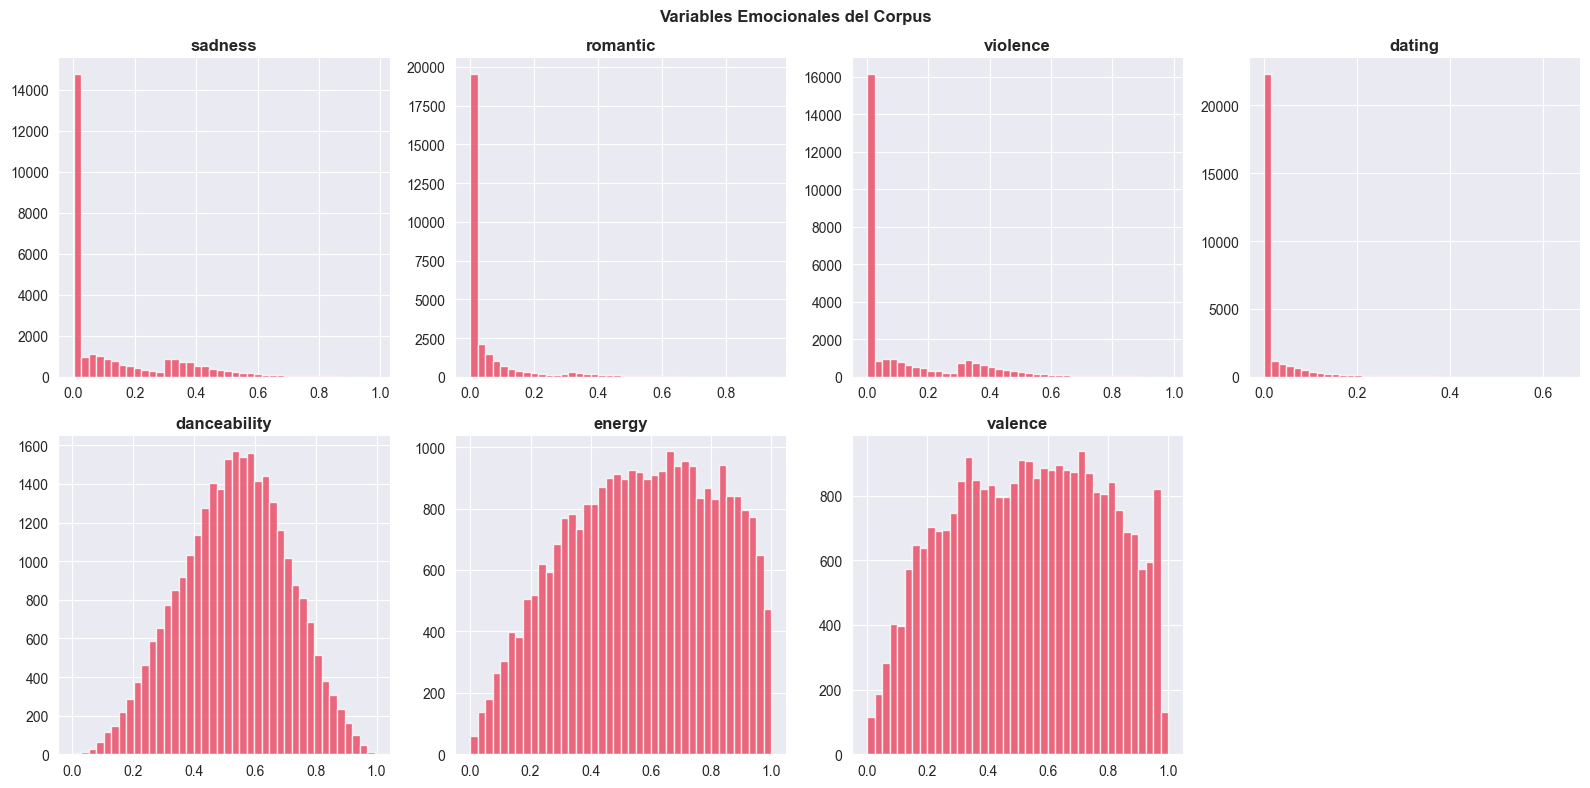

In [6]:
emociones = ['sadness', 'romantic', 'violence', 'dating', 'danceability', 'energy', 'valence']
disponibles = [c for c in emociones if c in df.columns]

print('Columnas emocionales:', disponibles)
print()
print(df[disponibles].describe().round(3))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(disponibles):
    axes[i].hist(df[col].dropna(), bins=40, color='#e94560', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].spines[['top','right']].set_visible(False)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Variables Emocionales del Corpus', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'variables_emocionales.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Muestras representativas por género

In [7]:
print('=== EJEMPLOS DE LETRAS POR GENERO ===')
for genero in sorted(df['genre'].unique()):
    sample = df[(df['genre'] == genero) & (df['lyrics'].notna())].sample(1, random_state=42)
    row = sample.iloc[0]
    letra = str(row['lyrics'])[:180].replace('\n', ' ')
    print(f'\n[{genero.upper()}] {row["track_name"]} --- {row["artist_name"]} ({int(row["release_date"])})')
    print(f'  {letra}...')

=== EJEMPLOS DE LETRAS POR GENERO ===

[BLUES] shake it baby --- john lee hooker (1966)
  shake baby shake baby shake baby shake right waaaaaaah yeah shake baby shake baby shake thing shake baby shake baby shake baby time time hahaha shake thing baby time daddy cookin j...

[COUNTRY] lay it down --- waylon jennings (1973)
  travelin different roads tryin hard leave load hard try disatisfied seek wisdom deny tryin hard brother hard hide confide think time try speak unashamed need play game tryin hard w...

[HIP HOP] hip hop adictos --- sabotaje mexica (2003)
  people people people dream set night fall hoe pull wave know showin bling drive pull thing girl catch feel throw ring dream thing go problems gotta work kink sleep think bout divor...

[JAZZ] if only she woulda --- frank zappa (1981)
  take jumbo woulda give shove send late letter today life leave shaft draft...

[POP] everybody's talkin' --- neil diamond (1973)
  everybody talkin hear word sayin echo mind people stoppin starin fa

## 6. Resumen

| Campo | Valor |
|---|---|
| Total canciones | 28,372 |
| Artistas únicos | ~8,000 |
| Géneros | 7 |
| Rango temporal | 1950–2019 |
| Con letra | 28,319 |
| Variables emocionales | 7 |

In [8]:
resumen = {
    'total_canciones'     : int(len(df)),
    'artistas_unicos'     : int(df['artist_name'].nunique()),
    'generos'             : df['genre'].value_counts().to_dict(),
    'rango_temporal'      : {'inicio': int(df['release_date'].min()), 'fin': int(df['release_date'].max())},
    'letras_disponibles'  : int(df['lyrics'].notna().sum()),
    'longitud_media'      : float(df['lyrics_len'].mean()),
    'columnas_emocionales': disponibles,
}
with open(RESULTS_DIR / 'corpus_stats.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)
print('corpus_stats.json guardado.')

corpus_stats.json guardado.


## Ejercicios

1. ¿Qué género tiene las letras más largas en promedio?
2. ¿Cómo evolucionó la longitud de las letras por década?
3. ¿Existe correlación entre `sadness` y `valence`?

In [9]:
# Espacio para ejercicios